# Markov Chain Graph Model for Stock Returns — Framework Design

## 1. Financial Setting

**Recommended asset: S&P 500 ETF (SPY) or a liquid single stock (e.g. AAPL, JPM)**

| Option | Pros | Cons |
|---|---|---|
| **SPY / S&P 500 index** | Highly liquid, low idiosyncratic noise, long history, broadly studied | Less alpha opportunity — very efficient |
| **Single liquid stock (AAPL)** | Richer dynamics, regime shifts around earnings | Exposed to firm-specific events that violate stationarity |
| **Small basket (3‑5 stocks)** | Can build *coupled* Markov chains or a joint state space | State space explodes combinatorially |

**Recommendation for this study:** Start with **SPY daily returns** (the S&P 500 index data you already have in `snp_500_2015_2019.csv` and `priceData.csv`). SPY has:
- Minimal survivorship bias or delisting issues.
- Enough mean-reversion and momentum structure for a Markov model to exploit.
- A long history for robust transition matrix estimation.

Once the pipeline works, extend to a single stock (AAPL) or a small sector basket to test robustness.

## 2. Time Horizon / Regime Period

**Recommended frequency: Daily returns**

| Frequency | Markov suitability | Trading horizon | Practical notes |
|---|---|---|---|
| **Tick / 1-min** | Very noisy; microstructure dominates | Ultra-short (HFT) | Needs order-book data, latency constraints |
| **30-min / Hourly** | Intraday momentum exists but transitions are noisy | Intraday | High transaction cost relative to signal |
| **Daily** ✅ | Good balance of signal and sample size | Swing trading (1–10 days) | ~252 obs/year; easy to source; well-studied |
| **Weekly** | Smoother but fewer observations | Medium-term | ~52 obs/year — slow to estimate transitions |
| **Monthly** | Strong regime structure but tiny sample | Tactical allocation | Only ~12 obs/year |

### Why daily?
- **Sample size**: 5 years of daily data ≈ 1,260 observations — enough to estimate a 5×5 transition matrix (25 parameters) with ~50 transitions per cell on average.
- **Signal**: Daily returns exhibit mild autocorrelation, volatility clustering, and mean reversion — exactly the patterns a Markov chain can capture.
- **Actionability**: A daily trading signal is practical to execute with reasonable transaction costs.
- **Examination scope**: Aligns well with a short-horizon active strategy that can be backtested meaningfully.

## 3. Discretising Daily Returns into States

The key design choice is mapping continuous daily log-returns $r_t = \ln(P_t / P_{t-1})$ into a finite set of states $S = \{s_1, s_2, \dots, s_K\}$.

### 3.1 Recommended approach: Quantile-based bins (5 states)

Use the **training-period empirical quantiles** to define boundaries. This ensures roughly equal counts per state, which gives well-estimated transition probabilities.

| State | Label | Quantile range | Typical daily return range (SPY) |
|---|---|---|---|
| $s_1$ | **Large Down** | $[0\%, 10\%)$ | $r_t < -1.3\%$ |
| $s_2$ | **Small Down** | $[10\%, 40\%)$ | $-1.3\% \le r_t < -0.2\%$ |
| $s_3$ | **Flat** | $[40\%, 60\%)$ | $-0.2\% \le r_t < +0.2\%$ |
| $s_4$ | **Small Up** | $[60\%, 90\%)$ | $+0.2\% \le r_t < +1.3\%$ |
| $s_5$ | **Large Up** | $[90\%, 100\%]$ | $r_t \ge +1.3\%$ |

> The exact thresholds above are illustrative for SPY 2015–2019. In practice, compute quantiles from the training set.

### 3.2 Alternative: Fixed-width bins

Define states using fixed return thresholds (e.g. $\{< -2\%,\; [-2\%, -0.5\%),\; [-0.5\%, +0.5\%),\; [+0.5\%, +2\%),\; \ge +2\%\}$). Simpler but may produce very unequal bin counts.

### 3.3 Alternative: Volatility-scaled bins

Normalise returns by a rolling volatility estimate $\hat\sigma_t$ and bin the standardised return $z_t = r_t / \hat\sigma_t$. This adapts the grid to changing volatility regimes and may improve stationarity of the chain.

### 3.4 Why 5 states?

- **3 states** (down / flat / up) is too coarse — loses tail information.
- **5 states** is a good sweet spot: captures tails, is easy to visualise, and keeps the transition matrix estimable with ~1,000 observations.
- **7+ states** risks sparse cells unless you have many years of data.

## 4. Graph Representation of the Markov Chain

### 4.1 The directed weighted graph

A first-order Markov chain with $K$ states maps naturally to a **directed weighted graph** $G = (V, E, w)$:

- **Vertices** $V = \{s_1, \dots, s_K\}$: one node per discretised return state.
- **Directed edges** $E$: an edge $(s_i, s_j)$ exists if the estimated transition probability $\hat{p}_{ij} > 0$.
- **Edge weights** $w(s_i, s_j) = \hat{p}_{ij}$: the maximum-likelihood estimate of $P(S_{t+1} = s_j \mid S_t = s_i)$, computed as:

$$\hat{p}_{ij} = \frac{n_{ij}}{\sum_{k=1}^{K} n_{ik}}$$

where $n_{ij}$ = number of observed transitions from state $i$ to state $j$ in the training data.

### 4.2 The transition matrix as an adjacency matrix

The $K \times K$ transition matrix $\mathbf{P}$ is exactly the **weighted adjacency matrix** of the graph, where each row sums to 1 (a row-stochastic matrix).

$$
\mathbf{P} = \begin{pmatrix}
p_{11} & p_{12} & \cdots & p_{1K} \\
p_{21} & p_{22} & \cdots & p_{2K} \\
\vdots & & \ddots & \vdots \\
p_{K1} & p_{K2} & \cdots & p_{KK}
\end{pmatrix}
$$

### 4.3 Why is the graph view useful?

1. **Visualisation**: Drawing the graph with `networkx` makes regime dynamics immediately visible — you can see which states are "sticky" (strong self-loops) and which transitions dominate.

2. **Path analysis**: Graph algorithms (shortest path, PageRank, community detection) reveal structural properties:
   - **Stationary distribution** $\boldsymbol{\pi}$ (= PageRank with damping = 1): tells you the long-run fraction of time spent in each state.
   - **Mean first passage times**: how many days, on average, to reach a Large Up state from a Large Down state — computable via graph-theoretic formulas.
   - **Communicating classes**: if some states are transient, the graph decomposes into components.

3. **Optimisation on graphs**: Formulating trading as a flow or path problem on the graph opens access to well-studied combinatorial optimisation tools (see Section 6).

4. **Higher-order models**: A second-order Markov chain (conditioning on 2 past states) can be represented as a graph on $K^2$ nodes, where each node is a *pair* of consecutive states — the graph framework extends naturally.

## 5. Deriving a Trading Rule from Transition Probabilities

### 5.1 Core idea: Expected next-day return

Given the current state $s_i$, compute the **conditional expected return** for tomorrow:

$$\hat{\mu}_i = \sum_{j=1}^{K} \hat{p}_{ij} \cdot \bar{r}_j$$

where $\bar{r}_j$ is the **average realised return** within state $j$ (computed from training data). This is the expected return of holding the asset for one day, conditional on being in state $s_i$ today.

### 5.2 Simple threshold rule

$$
\text{Position}_{t+1} = 
\begin{cases}
+1 \;\text{(long)} & \text{if } \hat{\mu}_{s_t} > c \\
0 \;\text{(flat)} & \text{if } |\hat{\mu}_{s_t}| \le c \\
-1 \;\text{(short)} & \text{if } \hat{\mu}_{s_t} < -c
\end{cases}
$$

where $c \ge 0$ is a **transaction-cost buffer** (e.g. $c = 0.05\%$ to avoid trading on tiny edges). If short-selling is not permitted, replace $-1$ with $0$.

### 5.3 Probability-weighted rule (risk-aware)

Instead of just the expected return, incorporate the **probability of a favourable move**:

$$P(\text{up} \mid s_i) = \sum_{j : \bar{r}_j > 0} \hat{p}_{ij}$$

Go long only when *both* $\hat{\mu}_i > c$ **and** $P(\text{up} \mid s_i) > 0.5$. This avoids states where a small probability of a huge gain inflates the expected return but the most likely outcome is negative.

### 5.4 Multi-step lookahead

The Markov property allows you to compute the **$n$-step transition matrix** $\mathbf{P}^n$ and derive expected returns over a horizon of $n$ days:

$$\hat{\mu}_i^{(n)} = \sum_{j=1}^K [\mathbf{P}^n]_{ij} \cdot \bar{r}_j$$

This is useful for a strategy that holds positions for more than one day. The graph interpretation: $[\mathbf{P}^n]_{ij}$ is the probability of a length-$n$ walk from node $i$ to node $j$.

## 6. Optimisation Problem on the Graph

This is where the graph framework adds genuine value beyond a simple look-up table.

### 6.1 Optimal stationary policy (Markov Decision Process formulation)

Model the problem as an **MDP** on the Markov chain graph:

- **States**: $S = \{s_1, \dots, s_K\}$ (the return-regime nodes)
- **Actions**: at each state, choose $a \in \{\text{long}, \text{flat}, \text{short}\}$
- **Rewards**: if in state $s_i$ and action is $a$:
$$R(s_i, a) = a \cdot \bar{r}_i - \kappa \cdot |a - a_{\text{prev}}|$$
where $\kappa$ is a per-trade transaction cost (penalises switching).
- **Transition probabilities**: $P(s_j \mid s_i, a) = \hat{p}_{ij}$ (the action does not affect the market — a reasonable assumption for a small trader).

**Objective — maximise the long-run average reward:**

$$\max_{\pi: S \to A} \;\; \sum_{i=1}^K \pi_i \cdot R(s_i, \pi(s_i))$$

subject to $\pi_i$ being the stationary distribution induced by the policy. Equivalently, solve for the **gain** $g^*$ in the Bellman equation:

$$g^* + V(s_i) = \max_{a \in A}\left[ R(s_i, a) + \sum_{j} \hat{p}_{ij} \, V(s_j) \right] \quad \forall \, i$$

This is solvable by **value iteration** or **linear programming** on the graph. With only $K = 5$ states and 3 actions, it is trivially fast.

### 6.2 Optimal path / maximum expected reward path

Reformulate edge weights as **expected rewards**: set $w(s_i, s_j) = \hat{p}_{ij} \cdot \bar{r}_j$ and find the path through the graph that maximises cumulative expected reward over an $n$-step horizon. This becomes a **longest path in a DAG** if you unroll the graph over time (which is always acyclic).

### 6.3 Graph-constrained portfolio optimisation (multi-asset extension)

If you build one Markov chain per asset, you can define a **graph-constrained mean-variance problem**:

$$
\max_{\mathbf{w}} \;\; \mathbf{w}^\top \hat{\boldsymbol{\mu}} - \frac{\lambda}{2} \mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w}
$$

where $\hat{\boldsymbol{\mu}}$ is the vector of conditional expected returns from each asset's Markov chain, and an additional **graph constraint** restricts which assets can be held together (e.g. only assets currently in "favourable" graph states).

### 6.4 Constraints to include

| Constraint | Formula | Rationale |
|---|---|---|
| Fully invested or flat | $\sum_a w_a \le 1$ | No leverage |
| No short-selling | $w_a \ge 0$ | Common restriction |
| Turnover limit | $\sum_a |w_a^{new} - w_a^{old}| \le \tau$ | Limits transaction costs |
| Minimum confidence | Trade only if $\hat{p}_{ij}$ is estimated from $\ge N_{\min}$ transitions | Avoids acting on noisy estimates |

## 7. Weaknesses and Limitations

| Weakness | Explanation | Mitigation |
|---|---|---|
| **First-order assumption** | A first-order chain assumes tomorrow depends *only* on today's state, ignoring longer memory (momentum, trend). | Use a second-order chain (pairs of states as nodes, $K^2$ nodes) or add features like lagged volatility to the state definition. |
| **Stationarity assumption** | The transition matrix is assumed constant over the training window. In reality, market regimes shift (e.g. bull → crisis). | Use a **rolling window** to re-estimate $\mathbf{P}$ periodically (e.g. every quarter). Or use a regime-switching model where you have *multiple* transition matrices. |
| **Discretisation information loss** | Binning continuous returns discards information (a −3% day and a −1.5% day both become "Large Down"). | Use finer bins if data permits, or keep track of conditional return distributions within each bin, not just means. |
| **Overfitting** | With $K$ states, you have $K(K-1)$ free parameters. If $K$ is large or the training window short, estimates are noisy. | Keep $K$ small (≤ 7). Apply Bayesian shrinkage or Laplace smoothing to transition counts: $\hat{p}_{ij} = (n_{ij} + \alpha) / (\sum_k n_{ik} + K\alpha)$. |
| **Transaction costs** | Frequent state changes may trigger daily trading, eroding profits via spreads and commissions. | Build transaction costs into the optimisation (Section 6.1) and impose turnover constraints. |
| **No exogenous information** | The model ignores fundamentals, macroeconomic news, earnings, etc. | Augment the state space with external signals (e.g. VIX regime, volume regime). |
| **Market impact** | Assumes trades have no price impact — fine for a small academic study, unrealistic at scale. | Not a concern for this study, but note it as a limitation. |
| **Look-ahead bias risk** | If quantile boundaries are computed using test data, you leak future information. | Always compute bin thresholds from the **training set only** and apply them to the test set. |

## 8. Train / Test Split and Out-of-Sample Evaluation

### 8.1 Recommended split strategy: Expanding window (walk-forward)

**Never shuffle time-series data.** Use a chronological split.

#### Option A — Simple split (good starting point)

Using your `snp_500_2015_2019.csv` data (2015-01-02 to ~2019-12-31):

| Set | Period | Purpose |
|---|---|---|
| **Training** | 2015-01 to 2017-12 (~756 trading days) | Estimate transition matrix $\mathbf{P}$, compute quantile bins, solve optimisation |
| **Validation** | 2018-01 to 2018-12 (~252 days) | Tune $K$, threshold $c$, rolling window length |
| **Test** | 2019-01 to 2019-12 (~252 days) | Final out-of-sample performance evaluation |

#### Option B — Walk-forward (rolling) backtest

1. Fix a **training window** of $W$ days (e.g. $W = 504$ ≈ 2 years).
2. At each rebalance date $t$:
   - Estimate $\mathbf{P}$ from days $[t - W, t - 1]$.
   - Compute quantile bins from the same window.
   - Generate the trading signal for day $t$.
   - Record the realised return.
3. Slide the window forward by 1 day (or 1 week) and repeat.

This avoids a single arbitrary split and shows how the strategy degrades or adapts over time.

### 8.2 Evaluation metrics

| Metric | Formula / Description |
|---|---|
| **Cumulative return** | $\prod_t (1 + r_t^{\text{strategy}}) - 1$ |
| **Annualised Sharpe ratio** | $\frac{\bar{r}^{\text{excess}}}{\sigma} \times \sqrt{252}$ — the primary risk-adjusted metric |
| **Maximum drawdown** | Largest peak-to-trough loss — measures tail risk |
| **Hit rate** | Fraction of days the signal correctly predicts the sign of the return |
| **Turnover** | Average daily change in position — drives transaction cost |
| **Net return** | Gross return minus estimated transaction costs (e.g. 5 bps per trade) |
| **Benchmark comparison** | Compare against **buy-and-hold SPY** — the strategy must beat this to be useful |

### 8.3 Statistical significance

- Use a **Diebold-Mariano test** to check whether the strategy's squared forecast errors are significantly lower than the benchmark's.
- Report **bootstrapped confidence intervals** on the Sharpe ratio.
- Check if results are robust to varying $K$, $W$, and the transaction cost assumption.

## 9. Summary Pipeline

```
Raw price data
     │
     ▼
Compute daily log-returns  r_t = ln(P_t / P_{t-1})
     │
     ▼
Chronological train/test split
     │
     ▼
Discretise returns into K states using training-set quantiles
     │
     ▼
Count transitions  n_{ij}  →  estimate  P̂_{ij} = n_{ij} / Σ_k n_{ik}
     │
     ▼
Build directed weighted graph  G = (V, E, w)
     │
     ▼
Analyse graph: stationary distribution, mean passage times, PageRank
     │
     ▼
Solve MDP / derive trading rule from conditional expected returns
     │
     ▼
Backtest on test set  →  compute Sharpe, drawdown, hit rate
     │
     ▼
Compare to buy-and-hold benchmark
```

---
## 10. Reference Implementation

Below is a complete working implementation using your S&P 500 data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# ── 1. Load data and compute returns ──────────────────────────────────────────
df = pd.read_csv("snp_500_2015_2019.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df = df.dropna(subset=["log_return"]).reset_index(drop=True)

print(f"Date range: {df['Date'].iloc[0].date()} to {df['Date'].iloc[-1].date()}")
print(f"Total observations: {len(df)}")
df[["Date", "Close", "log_return"]].head(10)

Total observations: 1509
Date range: 2014-01-03 to 2019-12-31


In [47]:
# ── 2. Train / Test split ──────────────────────────────────────────────────────
# Data runs 2014-01-02 to 2019-12-31
train_end = "2017-12-31"
val_end = "2018-12-31"

train = df[df["Date"] <= train_end].copy()
val = df[(df["Date"] > train_end) & (df["Date"] <= val_end)].copy()
test = df[df["Date"] > val_end].copy()

print(f"Train: {len(train)} days  ({train['Date'].iloc[0].date()} to {train['Date'].iloc[-1].date()})")
print(f"Val:   {len(val)} days  ({val['Date'].iloc[0].date()} to {val['Date'].iloc[-1].date()})")
print(f"Test:  {len(test)} days  ({test['Date'].iloc[0].date()} to {test['Date'].iloc[-1].date()})")

Train: 1006 days  (2014-01-03 to 2017-12-29)
Val:   251 days  (2018-01-02 to 2018-12-31)
Test:  252 days  (2019-01-02 to 2019-12-31)


In [51]:
# ── 3. Discretise returns into K states (quantile-based) ──────────────────────
K = 5
state_labels = ["Large Down", "Small Down", "Flat", "Small Up", "Large Up"]

# Compute quantile boundaries from TRAINING data only (no look-ahead bias)
quantiles = [0.0, 0.10, 0.40, 0.60, 0.90, 1.0]
boundaries = train["log_return"].quantile(quantiles).values.copy()
boundaries[0] = -np.inf
boundaries[-1] = np.inf

print("State boundaries (from training set):")
for i in range(K):
    lo = boundaries[i]
    hi = boundaries[i + 1]
    print(f"  {state_labels[i]:12s}: [{lo:+.4f}, {hi:+.4f})")

def discretise(returns, boundaries):
    """Assign each return to a state index 0..K-1."""
    states = np.digitize(returns, boundaries[1:-1])  # bins: 0, 1, ..., K-1
    return states

train["state"] = discretise(train["log_return"].values, boundaries)
val["state"] = discretise(val["log_return"].values, boundaries)
test["state"] = discretise(test["log_return"].values, boundaries)

# Check bin counts
print("\nTraining set state counts:")
for i in range(K):
    count = (train["state"] == i).sum()
    print(f"  {state_labels[i]:12s}: {count:4d} ({count/len(train)*100:.1f}%)")

State boundaries (from training set):
  Large Down  : [-inf, -0.0084)
  Small Down  : [-0.0084, -0.0007)
  Flat        : [-0.0007, +0.0016)
  Small Up    : [+0.0016, +0.0091)
  Large Up    : [+0.0091, +inf)

Training set state counts:
  Large Down  :  101 (10.0%)
  Small Down  :  301 (29.9%)
  Flat        :  201 (20.0%)
  Small Up    :  302 (30.0%)
  Large Up    :  101 (10.0%)


In [52]:
# ── 4. Estimate transition matrix ─────────────────────────────────────────────
def estimate_transition_matrix(states, K, alpha=0.0):
    """
    Maximum-likelihood transition matrix with optional Laplace smoothing.
    alpha=0: pure MLE.  alpha>0: Bayesian smoothing.
    """
    counts = np.zeros((K, K))
    for t in range(len(states) - 1):
        i, j = states[t], states[t + 1]
        counts[i, j] += 1
    # Add smoothing
    counts += alpha
    # Normalise rows
    row_sums = counts.sum(axis=1, keepdims=True)
    P = counts / row_sums
    return P, counts - alpha  # return raw counts too

P_train, counts_train = estimate_transition_matrix(train["state"].values, K, alpha=1.0)

print("Transition count matrix:")
count_df = pd.DataFrame(counts_train.astype(int), index=state_labels, columns=state_labels)
print(count_df)
print("\nTransition probability matrix (with Laplace smoothing α=1):")
prob_df = pd.DataFrame(P_train.round(3), index=state_labels, columns=state_labels)
print(prob_df)

Transition count matrix:
            Large Down  Small Down  Flat  Small Up  Large Up
Large Down          19          16    16        26        24
Small Down          22          79    60       109        30
Flat                21          67    38        59        16
Small Up            21         111    70        83        17
Large Up            18          28    16        25        14

Transition probability matrix (with Laplace smoothing α=1):
            Large Down  Small Down   Flat  Small Up  Large Up
Large Down       0.189       0.160  0.160     0.255     0.236
Small Down       0.075       0.262  0.200     0.361     0.102
Flat             0.107       0.330  0.189     0.291     0.083
Small Up         0.072       0.365  0.231     0.274     0.059
Large Up         0.179       0.274  0.160     0.245     0.142


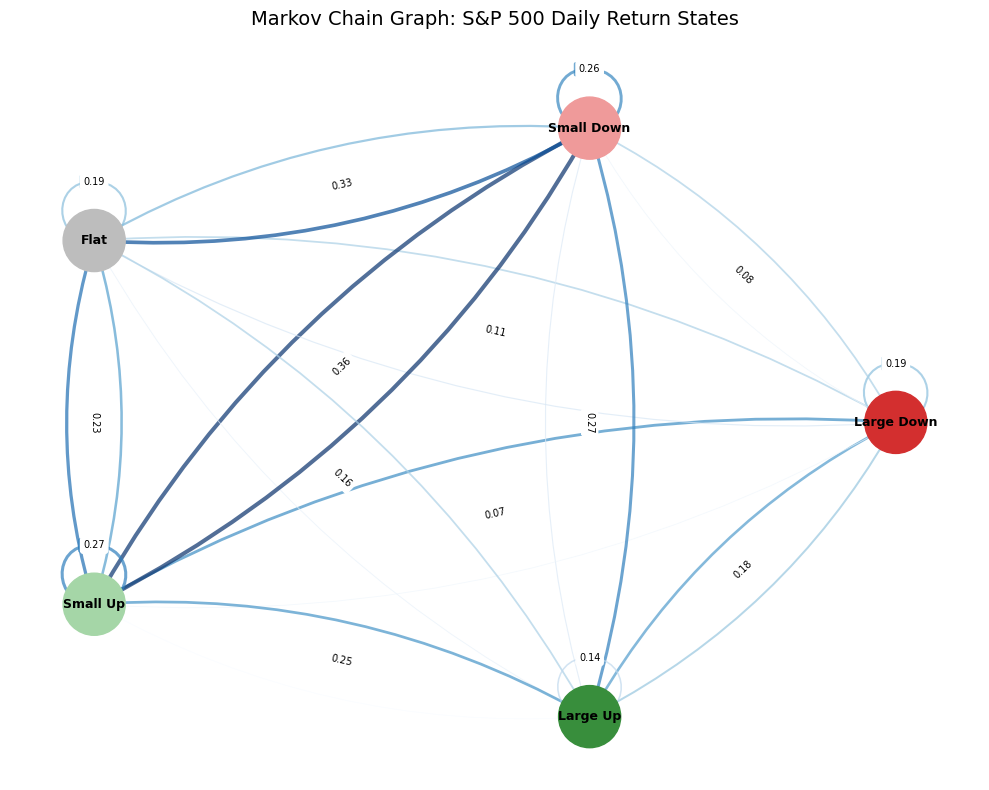

In [53]:
# ── 5. Build and visualise the Markov chain graph ─────────────────────────────
G = nx.DiGraph()

for i in range(K):
    G.add_node(i, label=state_labels[i])

for i in range(K):
    for j in range(K):
        if P_train[i, j] > 0.01:  # only draw edges with meaningful probability
            G.add_edge(i, j, weight=P_train[i, j])

# Layout and drawing
fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.circular_layout(G)

# Node colours: red for down states, grey for flat, green for up states
node_colors = ["#d32f2f", "#ef9a9a", "#bdbdbd", "#a5d6a7", "#388e3c"]

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color=node_colors, ax=ax)
nx.draw_networkx_labels(G, pos, labels={i: state_labels[i] for i in range(K)},
                        font_size=9, font_weight="bold", ax=ax)

# Draw edges with width proportional to probability
edges = G.edges(data=True)
edge_widths = [d["weight"] * 8 for _, _, d in edges]
edge_colors = [d["weight"] for _, _, d in edges]

nx.draw_networkx_edges(G, pos, edgelist=[(u, v) for u, v, _ in edges],
                       width=edge_widths, edge_color=edge_colors,
                       edge_cmap=plt.cm.Blues, alpha=0.7,
                       arrows=True, arrowsize=20,
                       connectionstyle="arc3,rad=0.15", ax=ax)

# Edge labels (probabilities)
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

ax.set_title("Markov Chain Graph: S&P 500 Daily Return States", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

In [54]:
# ── 6. Graph analysis: stationary distribution & mean first passage times ─────

# 6a. Stationary distribution (left eigenvector of P with eigenvalue 1)
eigenvalues, eigenvectors = np.linalg.eig(P_train.T)
# Find eigenvector for eigenvalue closest to 1
idx = np.argmin(np.abs(eigenvalues - 1.0))
stationary = np.real(eigenvectors[:, idx])
stationary = stationary / stationary.sum()  # normalise to sum to 1

print("Stationary distribution (long-run fraction of time in each state):")
for i in range(K):
    print(f"  {state_labels[i]:12s}: {stationary[i]:.4f} ({stationary[i]*100:.1f}%)")

# 6b. Mean first passage times (expected days to reach state j from state i)
# Solve: M[i,j] = 1 + Σ_{k≠j} P[i,k] * M[k,j]
def mean_first_passage(P):
    K = P.shape[0]
    M = np.zeros((K, K))
    for j in range(K):
        # For target state j, solve (I - Q) m = 1, where Q = P with column/row j removed
        mask = [k for k in range(K) if k != j]
        Q = P[np.ix_(mask, mask)]
        ones = np.ones(K - 1)
        m = np.linalg.solve(np.eye(K - 1) - Q, ones)
        for idx_m, k in enumerate(mask):
            M[k, j] = m[idx_m]
    return M

M = mean_first_passage(P_train)
print("\nMean first passage times (expected days to reach column state from row state):")
mfp_df = pd.DataFrame(M.round(1), index=state_labels, columns=state_labels)
print(mfp_df)

Stationary distribution (long-run fraction of time in each state):
  Large Down  : 0.1029 (10.3%)
  Small Down  : 0.2970 (29.7%)
  Flat        : 0.1990 (19.9%)
  Small Up    : 0.2981 (29.8%)
  Large Up    : 0.1029 (10.3%)

Mean first passage times (expected days to reach column state from row state):
            Large Down  Small Down  Flat  Small Up  Large Up
Large Down         0.0         3.8   5.2       3.5       8.7
Small Down        11.1         0.0   5.0       3.1      10.3
Flat              10.8         3.2   0.0       3.3      10.5
Small Up          11.2         3.0   4.8       0.0      10.8
Large Up           9.9         3.4   5.2       3.5       0.0


In [55]:
# ── 7. Trading rule: conditional expected return ──────────────────────────────

# Average realised return in each state (training set)
state_mean_return = train.groupby("state")["log_return"].mean().values
print("Mean return per state (training set):")
for i in range(K):
    print(f"  {state_labels[i]:12s}: {state_mean_return[i]*100:+.3f}%")

# Conditional expected next-day return given current state
cond_expected = P_train @ state_mean_return
print("\nConditional expected next-day return E[r_{t+1} | state_t = s_i]:")
for i in range(K):
    print(f"  {state_labels[i]:12s}: {cond_expected[i]*100:+.4f}%")

# P(next day up | current state)
prob_up = P_train[:, 3:].sum(axis=1)  # states "Small Up" + "Large Up"
print("\nP(up move tomorrow | current state):")
for i in range(K):
    print(f"  {state_labels[i]:12s}: {prob_up[i]:.3f}")

Mean return per state (training set):
  Large Down  : -1.455%
  Small Down  : -0.328%
  Flat        : +0.041%
  Small Up    : +0.448%
  Large Up    : +1.387%

Conditional expected next-day return E[r_{t+1} | state_t = s_i]:
  Large Down  : +0.1205%
  Small Down  : +0.1149%
  Flat        : -0.0111%
  Small Up    : -0.0107%
  Large Up    : -0.0380%

P(up move tomorrow | current state):
  Large Down  : 0.491
  Small Down  : 0.462
  Flat        : 0.374
  Small Up    : 0.332
  Large Up    : 0.387


In [56]:
# ── 7b. Validation: tune K (number of states) and alpha (smoothing) ───────────
# The validation set is used to select the best hyperparameters before
# evaluating on the held-out test set.
#
# Parameters being tuned:
#   K     — number of discretised return states (controls granularity)
#   alpha — Laplace smoothing strength (controls regularisation of transition matrix)

K_candidates = [3, 5, 7]
alpha_candidates = [0, 0.5, 1.0, 2.0]

results = []

for K_try in K_candidates:
    # Define quantile boundaries for K_try states
    q = np.linspace(0, 1, K_try + 1)
    # Use asymmetric quantiles for tail-heavy bins when K=5
    if K_try == 5:
        q = [0.0, 0.10, 0.40, 0.60, 0.90, 1.0]
    bounds = train["log_return"].quantile(q).values.copy()
    bounds[0] = -np.inf
    bounds[-1] = np.inf

    train_states = np.digitize(train["log_return"].values, bounds[1:-1])
    val_states = np.digitize(val["log_return"].values, bounds[1:-1])

    # Mean return per state from training set
    smr = np.array([train["log_return"].values[train_states == s].mean()
                     for s in range(K_try)])

    for alpha_try in alpha_candidates:
        P, _ = estimate_transition_matrix(train_states, K_try, alpha=alpha_try)

        # Solve MDP (no transaction costs)
        V = np.zeros(K_try)
        for _ in range(5000):
            V_new = np.zeros(K_try)
            pol = np.zeros(K_try, dtype=int)
            for i in range(K_try):
                best_val, best_a = -np.inf, 0
                for a in [-1, 0, 1]:
                    reward = a * (P[i] @ smr)
                    v = reward + 0.99 * (P[i] @ V)
                    if v > best_val:
                        best_val, best_a = v, a
                V_new[i] = best_val
                pol[i] = best_a
            if np.max(np.abs(V_new - V)) < 1e-8:
                break
            V = V_new

        # Backtest on validation set
        val_rets = []
        for t in range(len(val_states) - 1):
            pos = pol[val_states[t]]
            val_rets.append(pos * val["log_return"].iloc[t + 1])
        val_rets = np.array(val_rets)

        sharpe = (np.mean(val_rets) / np.std(val_rets) * np.sqrt(252)
                  if np.std(val_rets) > 0 else 0)
        total_ret = np.exp(np.sum(val_rets)) - 1
        results.append({
            "K": K_try, "alpha": alpha_try,
            "sharpe": sharpe, "total_return": total_ret,
            "policy": {s: {-1: "SHORT", 0: "FLAT", 1: "LONG"}[pol[s]] for s in range(K_try)}
        })

results_df = pd.DataFrame(results).sort_values("sharpe", ascending=False)
print("Validation set results (sorted by Sharpe):\n")
print(results_df[["K", "alpha", "sharpe", "total_return"]].to_string(index=False))

best = results_df.iloc[0]
print(f"\nBest: K={int(best['K'])}, alpha={best['alpha']}, "
      f"Sharpe={best['sharpe']:.3f}, Return={best['total_return']*100:+.2f}%")
print(f"Policy: {best['policy']}")

Validation set results (sorted by Sharpe):

 K  alpha    sharpe  total_return
 7    0.0  0.073832      0.012592
 7    0.5  0.073832      0.012592
 7    1.0  0.073832      0.012592
 7    2.0  0.073832      0.012592
 5    2.0 -0.594847     -0.095835
 5    1.0 -0.594847     -0.095835
 5    0.5 -0.594847     -0.095835
 5    0.0 -0.594847     -0.095835
 3    2.0 -1.823213     -0.264333
 3    1.0 -1.823213     -0.264333
 3    0.5 -1.823213     -0.264333
 3    0.0 -1.823213     -0.264333

Best: K=7, alpha=0.0, Sharpe=0.074, Return=+1.26%
Policy: {0: 'LONG', 1: 'LONG', 2: 'LONG', 3: 'SHORT', 4: 'SHORT', 5: 'LONG', 6: 'SHORT'}


In [57]:
# ── 7c. Re-fit with best hyperparameters from validation ──────────────────────
best_K = int(best["K"])
best_alpha = best["alpha"]
print(f"Re-fitting with K={best_K}, alpha={best_alpha}\n")

# Recompute quantile boundaries
if best_K == 5:
    quantiles = [0.0, 0.10, 0.40, 0.60, 0.90, 1.0]
else:
    quantiles = np.linspace(0, 1, best_K + 1).tolist()
boundaries = train["log_return"].quantile(quantiles).values.copy()
boundaries[0] = -np.inf
boundaries[-1] = np.inf

K = best_K
state_labels = [f"State {i}" for i in range(K)]
if K == 3:
    state_labels = ["Down", "Flat", "Up"]
elif K == 5:
    state_labels = ["Large Down", "Small Down", "Flat", "Small Up", "Large Up"]
elif K == 7:
    state_labels = ["Large Down", "Med Down", "Small Down", "Flat",
                    "Small Up", "Med Up", "Large Up"]

train["state"] = discretise(train["log_return"].values, boundaries)
val["state"] = discretise(val["log_return"].values, boundaries)
test["state"] = discretise(test["log_return"].values, boundaries)

P_train, counts_train = estimate_transition_matrix(train["state"].values, K, alpha=best_alpha)
state_mean_return = np.array([train.loc[train["state"] == s, "log_return"].mean()
                              for s in range(K)])

print("Updated transition matrix:")
print(pd.DataFrame(P_train.round(3), index=state_labels, columns=state_labels))
print("\nMean return per state:")
for i in range(K):
    print(f"  {state_labels[i]:12s}: {state_mean_return[i]*100:+.3f}%")

Re-fitting with K=7, alpha=0.0

Updated transition matrix:
            Large Down  Med Down  Small Down   Flat  Small Up  Med Up  \
Large Down       0.208     0.111       0.069  0.097     0.104   0.167   
Med Down         0.126     0.119       0.098  0.168     0.147   0.140   
Small Down       0.112     0.112       0.154  0.147     0.203   0.154   
Flat             0.132     0.208       0.160  0.111     0.139   0.125   
Small Up         0.147     0.154       0.154  0.224     0.119   0.133   
Med Up           0.076     0.146       0.208  0.160     0.160   0.167   
Large Up         0.201     0.153       0.153  0.090     0.125   0.118   

            Large Up  
Large Down     0.243  
Med Down       0.203  
Small Down     0.119  
Flat           0.125  
Small Up       0.070  
Med Up         0.083  
Large Up       0.160  

Mean return per state:
  Large Down  : -1.234%
  Med Down    : -0.366%
  Small Down  : -0.118%
  Flat        : +0.040%
  Small Up    : +0.221%
  Med Up      : +0.508%
  La

In [ ]:
# ── 7d. Markov chain graph for K=7 ─────────────────────────────────────────────
K7 = 7
state_labels_7 = ["Large Down", "Med Down", "Small Down", "Flat",
                  "Small Up", "Med Up", "Large Up"]

# Quantile boundaries for 7 states
q7 = np.linspace(0, 1, K7 + 1)
bounds_7 = train["log_return"].quantile(q7).values.copy()
bounds_7[0] = -np.inf
bounds_7[-1] = np.inf

train_states_7 = np.digitize(train["log_return"].values, bounds_7[1:-1])
P7, _ = estimate_transition_matrix(train_states_7, K7, alpha=best_alpha)

# Build directed graph
G7 = nx.DiGraph()
for i in range(K7):
    G7.add_node(i, label=state_labels_7[i])
for i in range(K7):
    for j in range(K7):
        if P7[i, j] > 0.01:
            G7.add_edge(i, j, weight=P7[i, j])

# Visualise
fig, ax = plt.subplots(figsize=(12, 10))
pos = nx.circular_layout(G7)

node_colors_7 = ["#b71c1c", "#d32f2f", "#ef9a9a", "#bdbdbd",
                  "#a5d6a7", "#388e3c", "#1b5e20"]

nx.draw_networkx_nodes(G7, pos, node_size=2000, node_color=node_colors_7, ax=ax)
nx.draw_networkx_labels(G7, pos, labels={i: state_labels_7[i] for i in range(K7)},
                        font_size=8, font_weight="bold", ax=ax)

edges = G7.edges(data=True)
edge_widths = [d["weight"] * 8 for _, _, d in edges]
edge_colors = [d["weight"] for _, _, d in edges]

nx.draw_networkx_edges(G7, pos, edgelist=[(u, v) for u, v, _ in edges],
                       width=edge_widths, edge_color=edge_colors,
                       edge_cmap=plt.cm.Blues, alpha=0.7,
                       arrows=True, arrowsize=20,
                       connectionstyle="arc3,rad=0.15", ax=ax)

edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G7, pos, edge_labels=edge_labels, font_size=6, ax=ax)

ax.set_title("Markov Chain Graph: S&P 500 Daily Return States (K=7)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

print("\nTransition matrix (K=7):")
print(pd.DataFrame(P7.round(3), index=state_labels_7, columns=state_labels_7))

In [58]:
# ── 8. MDP optimisation: value iteration ──────────────────────────────────────

def solve_mdp(P, state_mean_return, actions=[-1, 0, 1],
              gamma=0.99, tol=1e-8, max_iter=10000):
    """
    Solve the MDP via value iteration (no transaction costs).
    Reward for taking action a in state i = a * E[r_{t+1} | s_t = i].
    """
    K = P.shape[0]
    V = np.zeros(K)

    for iteration in range(max_iter):
        V_new = np.zeros(K)
        policy = np.zeros(K, dtype=int)
        for i in range(K):
            best_val = -np.inf
            best_a = 0
            for a in actions:
                reward = a * (P[i] @ state_mean_return)
                val = reward + gamma * (P[i] @ V)
                if val > best_val:
                    best_val = val
                    best_a = a
            V_new[i] = best_val
            policy[i] = best_a
        if np.max(np.abs(V_new - V)) < tol:
            print(f"Value iteration converged in {iteration + 1} iterations.")
            break
        V = V_new

    return policy, V

optimal_policy, V_star = solve_mdp(P_train, state_mean_return)

print("\nOptimal policy (MDP solution):")
action_labels = {-1: "SHORT", 0: "FLAT", 1: "LONG"}
for i in range(K):
    print(f"  {state_labels[i]:12s} → {action_labels[optimal_policy[i]]:5s}  (value: {V_star[i]:.6f})")

Value iteration converged in 1112 iterations.

Optimal policy (MDP solution):
  Large Down   → LONG   (value: 0.070396)
  Med Down     → LONG   (value: 0.070808)
  Small Down   → LONG   (value: 0.070132)
  Flat         → SHORT  (value: 0.069549)
  Small Up     → SHORT  (value: 0.070072)
  Med Up       → LONG   (value: 0.069943)
  Large Up     → SHORT  (value: 0.069833)


In [59]:
# ── 9. Backtest on test set ────────────────────────────────────────────────────

def backtest(data, policy):
    """
    Backtest a Markov-chain trading strategy (no transaction costs).
    Position is determined by the MDP policy given the current state.
    Return is position * next-day log-return.
    """
    positions = []
    returns_strat = []

    for t in range(len(data)):
        state = data["state"].iloc[t]
        pos = policy[state]

        if t < len(data) - 1:
            next_ret = data["log_return"].iloc[t + 1]
            returns_strat.append(pos * next_ret)
        positions.append(pos)

    return np.array(returns_strat), np.array(positions)

# Run backtest on test set
strat_returns, strat_positions = backtest(test, optimal_policy)
benchmark_returns = test["log_return"].iloc[1:].values  # buy-and-hold

def compute_metrics(returns, label="Strategy"):
    cum_ret = np.exp(np.cumsum(returns)) - 1
    ann_ret = np.mean(returns) * 252
    ann_vol = np.std(returns) * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    max_dd = np.min(cum_ret - np.maximum.accumulate(cum_ret))
    hit_rate = np.mean(returns > 0)
    print(f"\n{label}:")
    print(f"  Annualised return:  {ann_ret*100:+.2f}%")
    print(f"  Annualised vol:     {ann_vol*100:.2f}%")
    print(f"  Sharpe ratio:       {sharpe:.3f}")
    print(f"  Max drawdown:       {max_dd*100:.2f}%")
    print(f"  Hit rate:           {hit_rate*100:.1f}%")
    print(f"  Total return:       {cum_ret[-1]*100:+.2f}%")
    return cum_ret

cum_strat = compute_metrics(strat_returns, "Markov Chain MDP Strategy")
cum_bench = compute_metrics(benchmark_returns, "Buy & Hold Benchmark")


Markov Chain MDP Strategy:
  Annualised return:  +4.44%
  Annualised vol:     12.59%
  Sharpe ratio:       0.353
  Max drawdown:       -12.62%
  Hit rate:           49.4%
  Total return:       +4.52%

Buy & Hold Benchmark:
  Annualised return:  +25.34%
  Annualised vol:     12.49%
  Sharpe ratio:       2.029
  Max drawdown:       -8.02%
  Hit rate:           59.4%
  Total return:       +28.71%


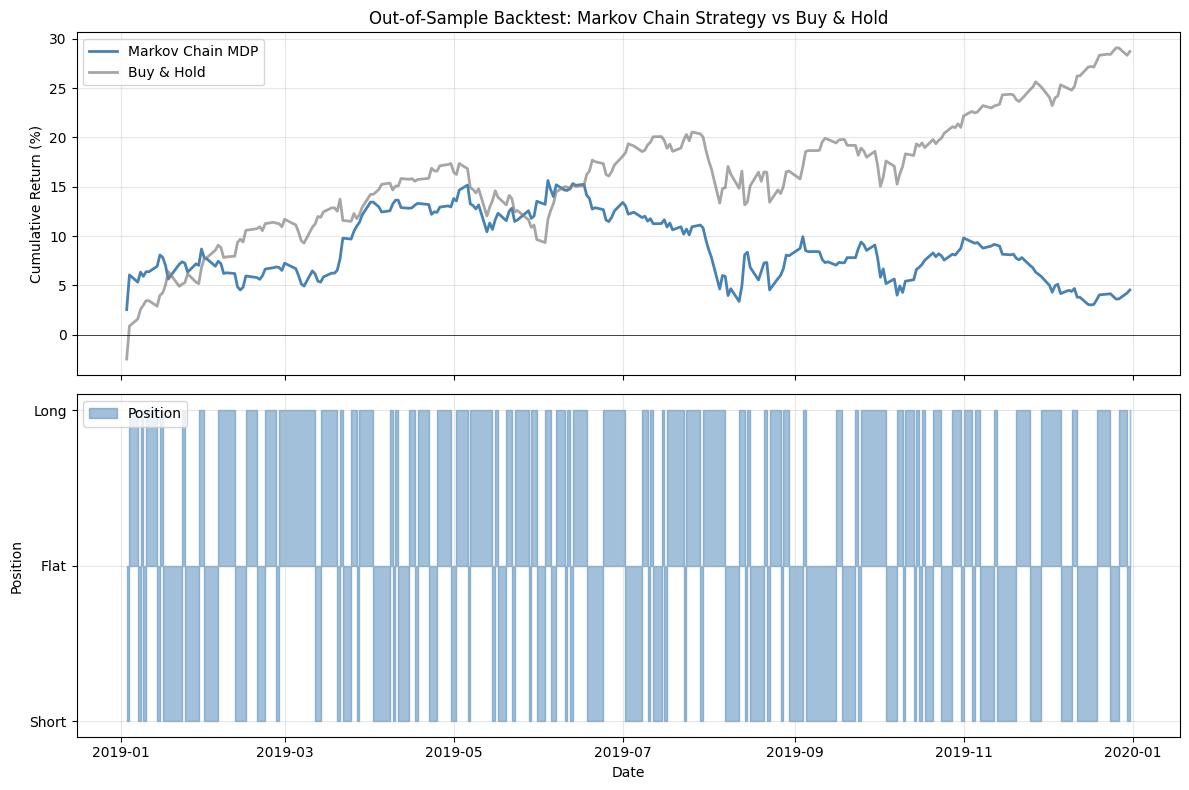

In [60]:
# ── 10. Plot cumulative returns ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Cumulative returns
dates = test["Date"].iloc[1:].values
axes[0].plot(dates, cum_strat * 100, label="Markov Chain MDP", linewidth=2, color="steelblue")
axes[0].plot(dates, cum_bench * 100, label="Buy & Hold", linewidth=2, color="grey", alpha=0.7)
axes[0].set_ylabel("Cumulative Return (%)")
axes[0].set_title("Out-of-Sample Backtest: Markov Chain Strategy vs Buy & Hold")
axes[0].legend()
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Positions over time
axes[1].fill_between(dates, strat_positions[:len(dates)], alpha=0.5, color="steelblue",
                     step="post", label="Position")
axes[1].set_ylabel("Position")
axes[1].set_xlabel("Date")
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(["Short", "Flat", "Long"])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

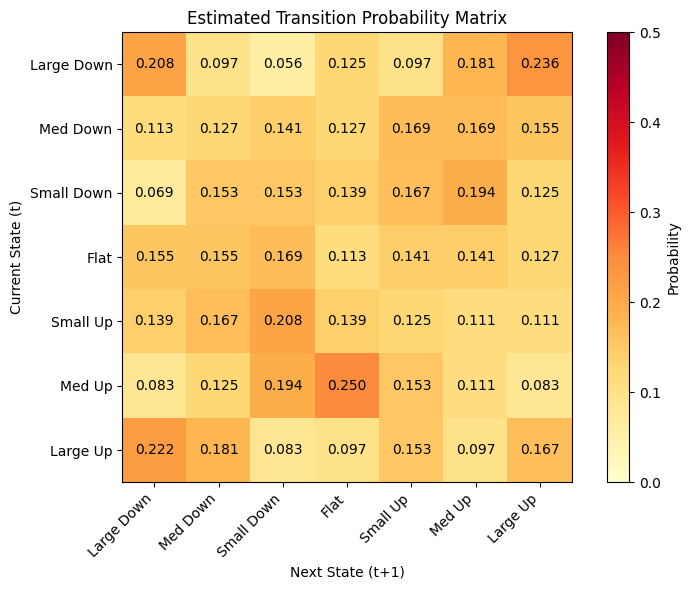

In [ ]:
# ── 11. Transition matrix heatmap ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(P_train, cmap="YlOrRd", vmin=0, vmax=0.5)

ax.set_xticks(range(K))
ax.set_yticks(range(K))
ax.set_xticklabels(state_labels, rotation=45, ha="right")
ax.set_yticklabels(state_labels)
ax.set_xlabel("Next State (t+1)")
ax.set_ylabel("Current State (t)")
ax.set_title("Estimated Transition Probability Matrix")

# Annotate cells
for i in range(K):
    for j in range(K):
        ax.text(j, i, f"{P_train[i,j]:.3f}", ha="center", va="center",
                color="white" if P_train[i,j] > 0.3 else "black", fontsize=10)

plt.colorbar(im, ax=ax, label="Probability")
plt.tight_layout()
plt.show()